In [1]:
import numpy as np
import pandas as pd
import kagglehub
import os
path=kagglehub.dataset_download('arashnic/book-recommendation-dataset')
print(os.listdir(path))

/home/ngh125/Documents/github/ml/30-Days-With-Machine-Learning/Week 3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['classicRec.png', 'DeepRec.png', 'Users.csv', 'Ratings.csv', 'recsys_taxonomy2.png', 'Books.csv']


In [2]:
books = pd.read_csv(
    f"{path}/Books.csv",
    sep=",",
    encoding="latin-1",
    on_bad_lines="skip"
)

users = pd.read_csv(
    f"{path}/Users.csv",
    sep=",",
    encoding="latin-1",
    on_bad_lines="skip"
)

ratings = pd.read_csv(
    f"{path}/Ratings.csv",
    sep=",",
    encoding="latin-1",
    on_bad_lines="skip"
)

/tmp/ipykernel_15501/4096374231.py:1: DtypeWarning: Columns (0: Year-Of-Publication) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv(


In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm

import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


In [5]:
books=books.rename(columns={"Book-Title": "Title", 
                      "Book-Author": "Author", 
                      "Year-Of-Publication": "Year",
                      "Image-URL-S ": "ImageS",
                      "Image-URL-M": "ImageM",
                      "Image-URL-L": "ImageL"})
users=users.rename(columns={"User-ID": "UserID",
                            },
                            )
ratings=ratings.rename(columns={"User-ID":"UserID",
                                "Book-Rating":"Rating"})

In [6]:
print(books.info())
print(users.info())
print(ratings.info())

<class 'pandas.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   ISBN         271360 non-null  str   
 1   Title        271360 non-null  str   
 2   Author       271358 non-null  str   
 3   Year         271360 non-null  object
 4   Publisher    271358 non-null  str   
 5   Image-URL-S  271360 non-null  str   
 6   ImageM       271360 non-null  str   
 7   ImageL       271357 non-null  str   
dtypes: object(1), str(7)
memory usage: 16.6+ MB
None
<class 'pandas.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   UserID    278858 non-null  int64  
 1   Location  278858 non-null  str    
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 6.4 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149

Expected ratings: 433,671
<class 'pandas.DataFrame'>
Index: 433671 entries, 1 to 1149779
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   UserID  433671 non-null  int64
 1   ISBN    433671 non-null  str  
 2   Rating  433671 non-null  int64
dtypes: int64(2), str(1)
memory usage: 13.2 MB
None


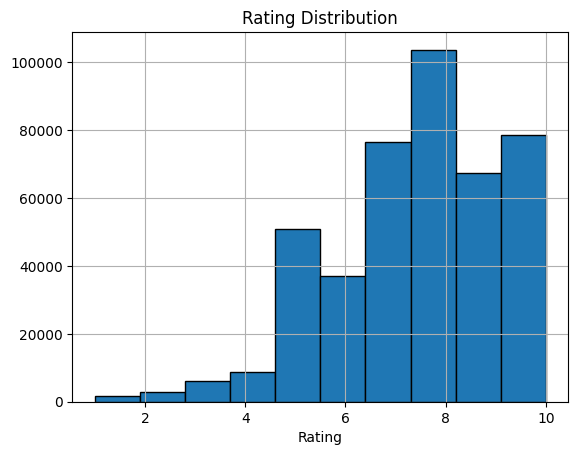

In [7]:
expectedRatings=ratings[ratings['Rating']>0].copy()

books["Year"]=pd.to_numeric(books["Year"],errors="coerce")
books['Year'] = books['Year'].where(books['Year'].between(1800, 2024))

users["Age"]=pd.to_numeric(users["Age"],errors="coerce")
users["Age"]=users["Age"].where(users["Age"].between(5,100))

print(f'Expected ratings: {len(expectedRatings):,}')
print(expectedRatings.info())
expectedRatings['Rating'].hist(bins=10, edgecolor='black')
plt.title('Rating Distribution');
plt.xlabel('Rating');
plt.show();

In [8]:
def FilterMinInteractions(df,userCol,itemCol,minU = 5,minI = 5):
    while True:
        uc=df[userCol].value_counts()
        ic=df[itemCol].value_counts()
        df=df[df[userCol].isin(uc[uc >= minU].index)]
        df=df[df[itemCol].isin(ic[ic >= minI].index)]
        if len(df[userCol].value_counts()[lambda x: x<minU])==0:
            break
    return df
df=FilterMinInteractions(expectedRatings,"UserID","ISBN")
itemEncoder=LabelEncoder();
userEncoder=LabelEncoder();
df["itemIdx"]=itemEncoder.fit_transform(df["ISBN"])
df["userIdx"]=userEncoder.fit_transform(df["UserID"])
N_USERS=int(df["userIdx"].max())+1
N_ITEMS=int(df["itemIdx"].max())+1
print("qualified user: ",N_USERS)
print("qualified user: ",N_ITEMS)

qualified user:  7027
qualified user:  9438


In [9]:
# split train_test build train sparse matrix
trainDf,testDf=train_test_split(df,train_size=0.8,random_state=0,stratify=df["Rating"])

scaler=MinMaxScaler()
trainDf["RatingNorm"]=scaler.fit_transform(trainDf[["Rating"]])
def buildMatrix(df,N_ITEMS,N_USERS,col="Rating"):
    matrix=sp.csr_matrix((df[col],(df["userIdx"],df["itemIdx"])),shape=(N_USERS,N_ITEMS),dtype=np.float32)
    return matrix
trainMatrix=buildMatrix(trainDf,N_ITEMS,N_USERS)
print('Train matrix shape:', trainMatrix.shape, '| Density:',
      f"{trainMatrix.nnz / (N_USERS * N_ITEMS):.4%}")

Train matrix shape: (7027, 9438) | Density: 0.1432%


In [10]:
#helper to calculate the rmse, recall, prediction rate

def rmse(yTrue,yPred):
    return np.sqrt(mean_squared_error(yTrue,yPred))
def precisionRecallAtK(predictions,k=10,threshold=7):
    userEstTrue=defaultdict(list)
    for uid,_,true,est,_ in predictions:
        userEstTrue[uid].append((true,est))
    precisions={};recalls={}
    for uid,ratings in userEstTrue.items():
        ratings.sort(key=lambda x:x[1],reverse=True)
        #loc nhung quyen duoc may danh gia cao
        userLiked=sum( t >=threshold for t,_ in ratings)
        predictLiked=sum(p>=threshold for _,p in ratings[:k])
        correct=sum(t>=threshold and p>=threshold for t,p in ratings[:k])
        precision=correct/userLiked if userLiked else 0
        recall=correct/predictLiked if predictLiked else 0
        precisions[uid]=precision
        recalls[uid]=recall
    return (np.mean(list(precisions.values())),np.mean(list(recalls.values())))
def hitRateAtK(Predictions,testDf,k=10):
    hits = 0
    users_tested = 0
    for uid in testDf['userIdx'].unique():
        true_items = set(testDf[testDf['userIdx']==uid]['itemIdx'].tolist())
        recs = Predictions(uid, k)
        #intersection
        if true_items & set(recs):
            hits += 1
        users_tested += 1
    return hits / users_tested if users_tested else 0
results={}

In [11]:
#cosine similarity on users

vals=trainDf["Rating"].astype(float).values
col=trainDf["itemIdx"].astype(int).values
row=trainDf['userIdx'].astype(int).values
matrixGpu = torch.zeros((N_USERS, N_ITEMS), dtype=torch.float32, device=device)
matrixGpu[row,col]=torch.tensor(vals,dtype=torch.float32,device=device)
globalRatingMean=np.mean(vals)
print(globalRatingMean)

#tinh mean cho tung nguoi deim trung binh cua moi nguoi
num=(matrixGpu>0).float().sum(dim=1).clamp(min=1)
meanPerson=matrixGpu.sum(dim=1)/num

#vector hoa mang danh gia
norms=matrixGpu.norm(dim=1,keepdim=True).clamp(min=1e-9)
normed=matrixGpu/norms
print(N_ITEMS)
#tinh ma tran tuong doi dua tren normed qua tung batch de chong tran
batchSize=512
simMatrix=torch.zeros((N_USERS, N_USERS),dtype=torch.float32,device=device)
for start in range (0,N_USERS,batchSize):
    end=min(start+batchSize,N_USERS)
    simMatrix[start:end]= normed[start:end] @ normed.T

#prediction based on simMatrix
testTuples = [
    (r.UserID, r.ISBN, r.Rating, r.userIdx, r.itemIdx)
    for r in testDf[['UserID','ISBN','Rating',"userIdx","itemIdx"]].itertuples()
]
k=20
preds=[]
for start in range(0,N_USERS,batchSize):
    end=min(N_USERS,start+batchSize)
    batch=testTuples[start:end]
    uIdx=torch.tensor([uIdex for _,_,_,uIdex,_ in batch],device=device)
    iIdx=torch.tensor([itemIdx for _,_,_,_,itemIdx in batch],device=device)

    simBatch=simMatrix[uIdx]
    #unsqueeze nen cac user idx thanh ma tran cot
    simBatch.scatter_(1,uIdx.unsqueeze(1),-1)
    topKSims,topKIdx=torch.topk(simBatch,k,dim=1)
    #access to rating of neighbors for target items
    nbRatings=matrixGpu[topKIdx.view(-1),iIdx.repeat_interleave(k)].view(len(batch),k)
    nbMean=meanPerson[topKIdx.view(-1)].view(len(batch),k)
    targetMean=meanPerson[uIdx]
    
    #prediction on KNN  with formula
    mask=nbRatings>0
    tu=(topKSims*(nbRatings-nbMean)*mask).sum(dim=1)
    mau=(topKSims*mask).sum(dim=1).clamp(min=1e-9)
    hasNeighBor=mask.sum(dim=1)>0
    pred=torch.where(hasNeighBor,targetMean+tu/mau,targetMean)
    pred=pred.clamp(1,10).cpu().numpy()

    for(uid,iid,trueR,_,_),p in zip(batch,pred):
        preds.append((uid,iid,trueR,float(p),{}))

actuals=np.array([t for  _,_,t,_,_ in preds])
predictions=np.array([p for _,_,_,p,_ in preds])
rmse_ubcf=np.sqrt(mean_squared_error(actuals,predictions))
p,r=precisionRecallAtK(preds)
results["Item-CF"]={'RMSE':rmse_ubcf,"p@10":p,"r@10":r}
print(f'item-CF RMSE={rmse_ubcf:.4f} P@10={p:.4f} r@10={r:.4f}')


7.810792026032288
9438


/tmp/ipykernel_15501/1101259614.py:7: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  matrixGpu[row,col]=torch.tensor(vals,dtype=torch.float32,device=device)


item-CF RMSE=1.6462 P@10=0.7115 r@10=0.6763


In [12]:
#cosine on item

#tinh mean cua tung san pham
num=(matrixGpu>0).sum(dim=0).clamp(min=1)
meanItem=matrixGpu.sum(dim=0)/num
norms=matrixGpu.norm(dim=0,keepdim=True).clamp(min=1e-9)
normed=matrixGpu/norms
#vector hoa cac danh gia cua tung san pham
normed=normed.T
simMatrix=torch.zeros((N_ITEMS,N_ITEMS),dtype=torch.float32,device=device)
batchSize=512
itemDF=testDf.T
for start in range(0,N_ITEMS,batchSize):
    end=min(start+batchSize,N_ITEMS)
    simMatrix[start:end]=normed[start:end]@ normed.T
testTuples=[(r.UserID,r.ISBN,r.Rating,r.userIdx,r.itemIdx)
            for r in testDf[['UserID','ISBN','Rating',"userIdx","itemIdx"]].itertuples()]
preds=[]
for start in range(0,len(testTuples),batchSize):
    end=min(start+batchSize,len(testTuples))
    batch=testTuples[start:end]
    uIdx=torch.tensor([u for _,_,_,u,_ in batch],device=device)
    iIdx=torch.tensor([i for _,_,_,_,i in batch],device=device)
    simBatch=simMatrix[iIdx]
    simBatch.scatter_(1,iIdx.unsqueeze(1),-1)
    topKSims,topKIdx=torch.topk(simBatch,20,dim=1)
    neighborRating=matrixGpu[uIdx.repeat_interleave(20), topKIdx.view(-1)].view(len(batch),k)
    neighborMean = meanItem[topKIdx.view(-1)].view(len(batch), k)
    

    targetMean=meanItem[iIdx]
    mask=neighborRating>0
    tu=(topKSims*(neighborRating-neighborMean)*mask).sum(dim=1).clamp(min=0)
    mau=(topKSims*mask).sum(dim=1).clamp(min=1e-9)
    hasNeighBor=mask.sum(dim=1)>0
    pred=torch.where(hasNeighBor,targetMean+(tu/mau),targetMean)
    pred=pred.clamp(1,10).cpu().numpy()
    for (uid,iid,trueR,_,_),p in zip(batch,pred):
        preds.append((uid,iid,trueR,float(p),{}))
actuals=np.array([t for  _,_,t,_,_ in preds])
predictions=np.array([p for _,_,_,p,_ in preds])
rmse_ibcf=np.sqrt(mean_squared_error(actuals,predictions))
p,r=precisionRecallAtK(preds)
results["Item-CF"]={'RMSE':rmse_ubcf,"p@10":p,"r@10":r}
print(f'item-CF RMSE={rmse_ubcf:.4f} P@10={p:.4f} r@10={r:.4f}')

item-CF RMSE=1.6462 P@10=0.8005 r@10=0.7675


In [13]:
#matrix factorization
class FunkSVD(nn.Module):
    def __init__(self,nUsers,nItems,factor=150):
        super().__init__()
        self.userLayer=nn.Embedding(nUsers,factor)
        self.itemLayer=nn.Embedding(nItems,factor)
        self.userBias=nn.Embedding(nUsers,1)
        self.itemBias=nn.Embedding(nItems,1)

        nn.init.normal_(self.userLayer.weight,std=0.01)
        nn.init.normal_(self.itemLayer.weight,std=0.01)
        nn.init.zeros_(self.userBias.weight)
        nn.init.zeros_(self.itemBias.weight)
    def forward(self,u,i):
        dot=(self.userLayer(u)*self.itemLayer(i)).sum(dim=1)
        bias=self.userBias(u).squeeze(-1) + self.itemBias(i).squeeze(-1)
        return dot+bias+globalMeanTensor
globalMeanTensor = torch.tensor(globalRatingMean, dtype=torch.float32, device=device)
# trainU=torch.tensor(torch.from_numpy(row),dtype=torch.float32,device=device)
# trainI=torch.tensor(torch.from_numpy(col),dtype=torch.float32,device=device)
# trainR=torch.tensor(torch.from_numpy(vals),dtype=torch.float32,device=device)
trainU = torch.from_numpy(row).long().to(device)
trainI = torch.from_numpy(col).long().to(device)
trainR = torch.from_numpy(vals).float().to(device)
model= FunkSVD(nUsers=N_USERS,nItems=N_ITEMS,factor=150).to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-4)
scheduler=torch.optim.lr_scheduler.StepLR(optimizer=optimizer,step_size=10,gamma=0.5)
critetion=nn.MSELoss()

batchSize=1024
nEpochs=30
Dataset=torch.utils.data.TensorDataset(trainU,trainI,trainR)
loader=torch.utils.data.DataLoader(dataset=Dataset,batch_size=batchSize,shuffle=True)
for epoch in range(nEpochs):
    model.train()
    totalLost=0
    optimizer.zero_grad()
    for u,i,r in loader:
        pred=model(u,i).clamp(1,10)
        loss=critetion(pred,r)
        loss.backward()
        optimizer.step()
        totalLost+=loss.item()
    scheduler.step()
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{nEpochs}  loss={totalLost/len(loader):.4f}  lr={scheduler.get_last_lr()[0]:.5f}")

model.eval()
preds=[]
with torch.no_grad():
    for start in range(0,len(testTuples),batchSize):
        data=testTuples[start:start+batchSize]
        ub=torch.tensor([u for _ , _,_,u,_ in data],dtype=torch.int32,device=device)
        ib=torch.tensor([i for _ , _,_,_,i in data],dtype=torch.int32,device=device)
        p=model(ub,ib).clamp(1,10).cpu().numpy()
        for(u,i,t,_,_),p in zip(data,p):
            preds.append((u,i,t,float(p),{}))
actuals=np.array([t for _,_,t,_,_  in preds])
predictions=np.array([p for _,_,_,p,_ in preds])
rmse_svd=np.sqrt(mean_squared_error(actuals,predictions))
p,r=precisionRecallAtK(preds)
results['SVD'] = {'RMSE': rmse_svd, 'P@10': p, 'R@10': r}
print(f'SVD RMSE={rmse_svd:.4f}  P@10={p:.4f}  R@10={r:.4f}')

Epoch 5/30  loss=0.4438  lr=0.00100
Epoch 10/30  loss=0.3860  lr=0.00050
Epoch 15/30  loss=0.0769  lr=0.00050
Epoch 20/30  loss=0.0586  lr=0.00025
Epoch 25/30  loss=0.0414  lr=0.00025
Epoch 30/30  loss=0.0322  lr=0.00013
SVD RMSE=1.6508  P@10=0.8505  R@10=0.7760


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm import tqdm
knowIsbns=list(trainDf['itemIdx'].keys())
booksC=books.drop_duplicates('ISBN').set_index('ISBN')
booksC['content']=(booksC['Title'].fillna(' ')+' '+booksC['Author'].fillna('')+' '+booksC['Publisher'].fillna(''))
tfidf=TfidfVectorizer(max_features=5000,ngram_range=(1,2))
tfidfMatrix=tfidf.fit_transform(booksC['content'])
print(tfidfMatrix.shape)
nItem=len(knowIsbns)

tfidfGpu=torch.tensor(tfidfMatrix.toarray(),dtype=torch.float32)
norms=tfidfGpu.norm(dim=1,keepdim=True).clamp(1e-9)
normed=tfidfGpu/norms
#calculate cossine matrix
simItemTop={}
for start in range(0,nItem,500):
    end=min(start+500,nItem)
    tfidfGpu[start:end]=tfidfGpu @ normed.T

(271360, 5000)


RuntimeError: [enforce fail at alloc_cpu.cpp:127] err == 0. DefaultCPUAllocator: can't allocate memory: you tried to allocate 294544998400 bytes. Error code 12 (Cannot allocate memory)

In [ ]:
#content-based
usersToItem=trainDf.groupby('userIdx')['itemIdx'].apply(set).to_dict()
usertoRating={
    uid : dict(zip(grp['itemIdx'],grp['Rating']))
    for uid , grp in trainDf.groupby('userIdx')
}
def BookRecommend(userIdx,k):
    userRows=trainDf[trainDf['userIdx']==userIdx]
    if userRows.empty():
        return []
    topItems=topKIdx(k,'Rating')['userIdx']
    seen =usersToItem.get(userIdx,set())
    